# Goal
- Predict the season a person might travel based on behavioural features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import re
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import os
import joblib

In [2]:
server = 'DESKTOP-74CHGLL\SQLEXPRESS'
database = 'TRAVEL_ACTIVITIES'

connection_string = f"mssql+pyodbc://@{server}/{database}?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
engine = create_engine(connection_string)

In [3]:
query = """
select b.booking_date, b.travel_date, b.channel,
b.trip_type, b.cabin, b.airline, b.origin, b.destination, b.pax_count,
b.base_fare, b.taxes_usd, b.total_usd, b.cost_usd, b.profit_usd,
b.lead_time, b.season, p.passenger_type, p.gender, p.nationality, p.loyalty_member,
pa.payment_method, pa.paid_usd, pa.payment_date, s.dep_airport, 
s.arr_airport, s.dep_city, s.arr_city, s.dep_date, s.flight_duration, s.stop_type

from passengers p
left join bookings b
on p.booking_id = b.booking_id
left join payments pa
on b.booking_id = pa.booking_id
left join segments s
on b.booking_id = s.booking_id
where b.booking_status != 'Cancelled' and pa.payment_status = 'Paid'
"""

In [4]:
df = pd.read_sql(query, engine)

In [5]:
df.head()

,booking_date,travel_date,channel,trip_type,cabin,airline,origin,destination,pax_count,base_fare,...,payment_method,paid_usd,payment_date,dep_airport,arr_airport,dep_city,arr_city,dep_date,flight_duration,stop_type
0,2023-02-27,2023-03-02,Online,One-way,PremiumEconomy,WY,SHJ,DAC,1,419.07,...,KNet,486.39,2023-03-01,SHJ,DAC,Sharjah,Dhaka,2023-03-02,220,Direct
1,2016-02-17,2016-03-17,Online,One-way,Economy,ME,KWI,BEY,2,347.28,...,KNet,408.21,2016-02-18,KWI,BEY,Kuwait City,Beirut,2016-03-17,216,Direct
2,2016-02-17,2016-03-17,Online,One-way,Economy,ME,KWI,BEY,2,347.28,...,KNet,408.21,2016-02-18,KWI,BEY,Kuwait City,Beirut,2016-03-17,216,Direct
3,2023-05-17,2023-07-14,WhatsApp,One-way,PremiumEconomy,UK,KWI,CMB,5,2863.85,...,Cash,3386.73,2023-05-17,KWI,CMB,Kuwait City,Colombo,2023-07-14,215,Direct
4,2023-05-17,2023-07-14,WhatsApp,One-way,PremiumEconomy,UK,KWI,CMB,5,2863.85,...,Cash,3386.73,2023-05-17,KWI,CMB,Kuwait City,Colombo,2023-07-14,215,Direct


In [6]:
df.to_csv(r"C:\Users\USER\Documents\MY PORTFOLIO\Smart Travel Recommendation System\Travel Agency\Main_data.csv", index=False)

In [7]:
df.shape

(34593, 30)

In [8]:
df.head()

,booking_date,travel_date,channel,trip_type,cabin,airline,origin,destination,pax_count,base_fare,...,payment_method,paid_usd,payment_date,dep_airport,arr_airport,dep_city,arr_city,dep_date,flight_duration,stop_type
0,2023-02-27,2023-03-02,Online,One-way,PremiumEconomy,WY,SHJ,DAC,1,419.07,...,KNet,486.39,2023-03-01,SHJ,DAC,Sharjah,Dhaka,2023-03-02,220,Direct
1,2016-02-17,2016-03-17,Online,One-way,Economy,ME,KWI,BEY,2,347.28,...,KNet,408.21,2016-02-18,KWI,BEY,Kuwait City,Beirut,2016-03-17,216,Direct
2,2016-02-17,2016-03-17,Online,One-way,Economy,ME,KWI,BEY,2,347.28,...,KNet,408.21,2016-02-18,KWI,BEY,Kuwait City,Beirut,2016-03-17,216,Direct
3,2023-05-17,2023-07-14,WhatsApp,One-way,PremiumEconomy,UK,KWI,CMB,5,2863.85,...,Cash,3386.73,2023-05-17,KWI,CMB,Kuwait City,Colombo,2023-07-14,215,Direct
4,2023-05-17,2023-07-14,WhatsApp,One-way,PremiumEconomy,UK,KWI,CMB,5,2863.85,...,Cash,3386.73,2023-05-17,KWI,CMB,Kuwait City,Colombo,2023-07-14,215,Direct


In [9]:
df.isna().sum()

booking_date       0
travel_date        0
channel            0
trip_type          0
cabin              0
airline            0
origin             0
destination        0
pax_count          0
base_fare          0
taxes_usd          0
total_usd          0
cost_usd           0
profit_usd         0
lead_time          0
season             0
passenger_type     0
gender             0
nationality        0
loyalty_member     0
payment_method     0
paid_usd           0
payment_date       0
dep_airport        0
arr_airport        0
dep_city           0
arr_city           0
dep_date           0
flight_duration    0
stop_type          0
dtype: int64

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34593 entries, 0 to 34592
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   booking_date     34593 non-null  str    
 1   travel_date      34593 non-null  str    
 2   channel          34593 non-null  str    
 3   trip_type        34593 non-null  str    
 4   cabin            34593 non-null  str    
 5   airline          34593 non-null  str    
 6   origin           34593 non-null  str    
 7   destination      34593 non-null  str    
 8   pax_count        34593 non-null  int64  
 9   base_fare        34593 non-null  float64
 10  taxes_usd        34593 non-null  float64
 11  total_usd        34593 non-null  float64
 12  cost_usd         34593 non-null  float64
 13  profit_usd       34593 non-null  float64
 14  lead_time        34593 non-null  int64  
 15  season           34593 non-null  str    
 16  passenger_type   34593 non-null  str    
 17  gender           34593 

In [11]:
# convert date to datetime
def convert_date(df):
    df['booking_date'] = pd.to_datetime(df['booking_date'])
    df['travel_date'] = pd.to_datetime(df['travel_date'])
    df['payment_date'] = pd.to_datetime(df['payment_date'])
    df['dep_date'] = pd.to_datetime(df['dep_date'])
    return df

In [12]:
df = convert_date(df)

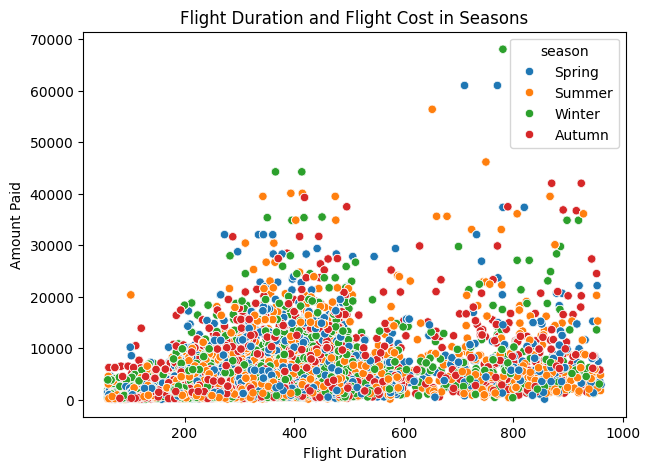

In [13]:
# Checking relationship between travel distance and travel cost with their season
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='flight_duration', y='paid_usd', hue='season')
plt.title("Flight Duration and Flight Cost in Seasons")
plt.xlabel('Flight Duration')
plt.ylabel('Amount Paid')
plt.show()

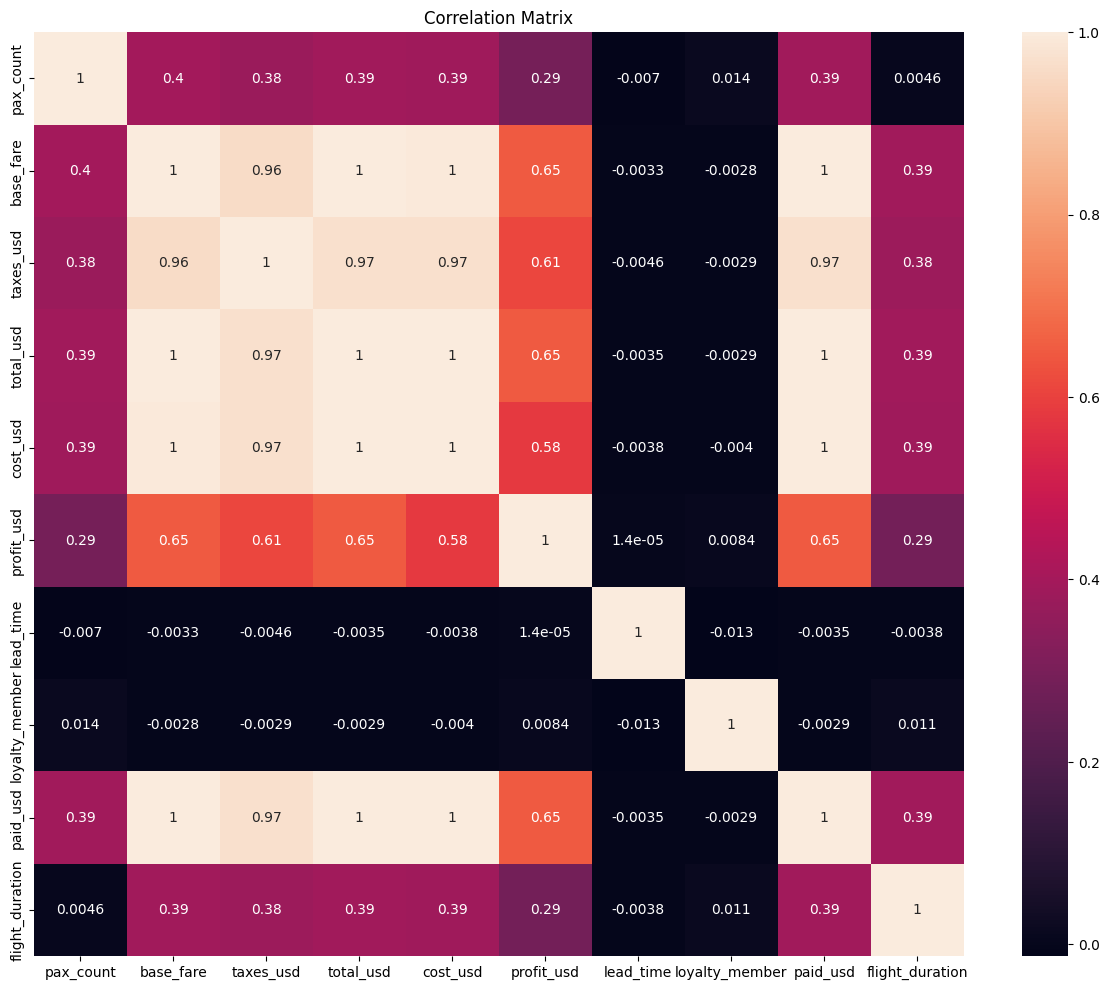

In [14]:
# correlation plot
corr = df.select_dtypes(include=["int", "float"]).corr()

plt.figure(figsize=(15, 12))
sns.heatmap(data=corr, annot=True)
plt.title("Correlation Matrix")

plt.show()

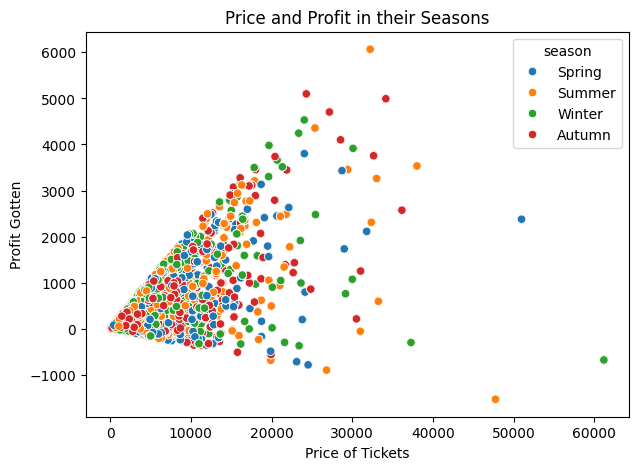

In [15]:
# Plot price and profit in seasons

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='base_fare', y='profit_usd', hue='season')
plt.title("Price and Profit in their Seasons")
plt.xlabel('Price of Tickets')
plt.ylabel('Profit Gotten')
plt.show()

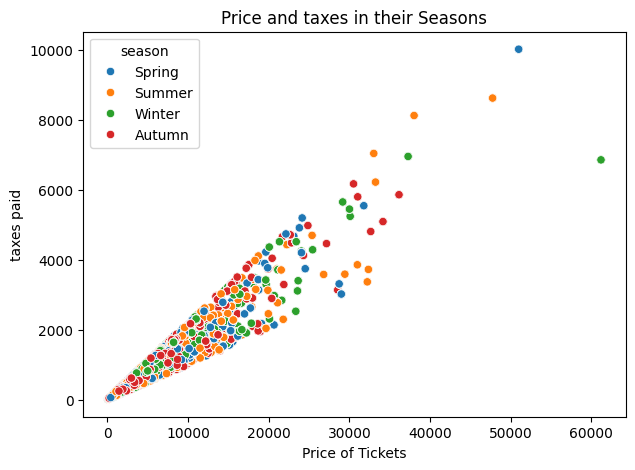

In [16]:
# Relationship between price of tickets and taxes by season

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='base_fare', y='taxes_usd', hue='season')
plt.title("Price and taxes in their Seasons")
plt.xlabel('Price of Tickets')
plt.ylabel('taxes paid')
plt.show()

In [17]:
# total_usd, paid_usd, cost_usd and base_fare are all same, we will drop 3 out of the 4
df.drop(['total_usd', 'cost_usd', 'base_fare'], axis=1, inplace=True)

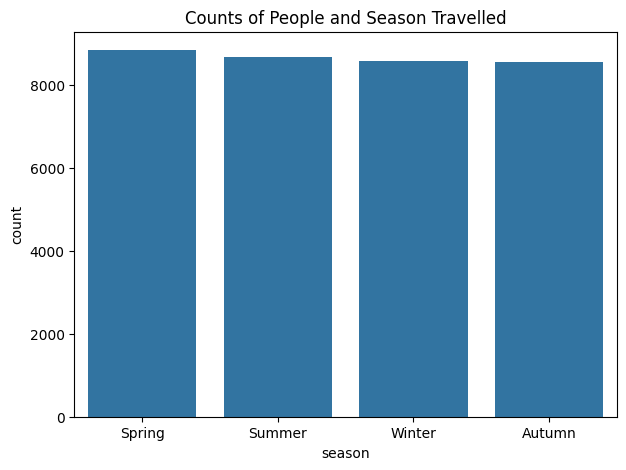

In [18]:
# Season People travels the most

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="season")
plt.title("Counts of People and Season Travelled")
plt.show()

# Feature Engineering

In [19]:
df

,booking_date,travel_date,channel,trip_type,cabin,airline,origin,destination,pax_count,taxes_usd,...,payment_method,paid_usd,payment_date,dep_airport,arr_airport,dep_city,arr_city,dep_date,flight_duration,stop_type
0,2023-02-27,2023-03-02,Online,One-way,PremiumEconomy,WY,SHJ,DAC,1,67.32,...,KNet,486.39,2023-03-01,SHJ,DAC,Sharjah,Dhaka,2023-03-02,220,Direct
1,2016-02-17,2016-03-17,Online,One-way,Economy,ME,KWI,BEY,2,60.93,...,KNet,408.21,2016-02-18,KWI,BEY,Kuwait City,Beirut,2016-03-17,216,Direct
2,2016-02-17,2016-03-17,Online,One-way,Economy,ME,KWI,BEY,2,60.93,...,KNet,408.21,2016-02-18,KWI,BEY,Kuwait City,Beirut,2016-03-17,216,Direct
3,2023-05-17,2023-07-14,WhatsApp,One-way,PremiumEconomy,UK,KWI,CMB,5,522.88,...,Cash,3386.73,2023-05-17,KWI,CMB,Kuwait City,Colombo,2023-07-14,215,Direct
4,2023-05-17,2023-07-14,WhatsApp,One-way,PremiumEconomy,UK,KWI,CMB,5,522.88,...,Cash,3386.73,2023-05-17,KWI,CMB,Kuwait City,Colombo,2023-07-14,215,Direct
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34588,2025-10-13,2025-11-02,Corporate,Round-trip,Economy,SG,AMM,CCU,2,294.48,...,Bank Transfer,2225.78,2025-10-17,CCU,AMM,Kolkata,Amman,2025-11-20,498,Direct
34589,2016-06-24,2016-08-21,Online,Round-trip,PremiumEconomy,VN,KWI,SGN,1,230.50,...,Card,1307.89,2016-06-25,KWI,SGN,Kuwait City,Ho Chi Minh,2016-08-21,325,Direct
34590,2016-06-24,2016-08-21,Online,Round-trip,PremiumEconomy,VN,KWI,SGN,1,230.50,...,Card,1307.89,2016-06-25,SGN,KWI,Ho Chi Minh,Kuwait City,2016-09-18,434,Direct
34591,2018-09-21,2018-09-26,WhatsApp,Round-trip,Economy,FZ,DXB,TPE,1,242.14,...,KNet,1687.25,2018-09-23,DXB,TPE,Dubai,Taipei,2018-09-26,529,Direct


In [20]:
def create_dist(df):
    df["Booking-Travel"] = df['travel_date'] - df['booking_date']
    df["Booking-Payment"] = df['payment_date'] - df['booking_date']
    df["Payment-Travel"] = df['travel_date'] - df['payment_date']
    df["Booking-dep"] = df['dep_date'] - df['booking_date']
    df["Payment-dep"] = df['dep_date'] - df['payment_date']
    df["Travel-dep"] = df['dep_date'] - df['travel_date']
    return df
df = create_dist(df)

In [21]:
cols = ["Booking-Travel", "Booking-Payment", "Payment-Travel", "Booking-dep", "Payment-dep", "Travel-dep"]

for col in cols:
    days = []

    for i in df[col].to_list():
        if "days" in str(i):
            days.append(i)
        else:
            print(f"Days not in {i}")
    
    if len(days) == len(df[col]):
        print(True)

True
True
True
True
True
True


In [22]:
def values(df):
    df["Booking-Travel"] = (df["Booking-Travel"].astype(str).str.extract(r"(\d+)")).astype(int)
    df["Booking-Payment"] = (df["Booking-Payment"].astype(str).str.extract(r"(\d+)")).astype(int)
    df["Payment-Travel"] = (df["Payment-Travel"].astype(str).str.extract(r"(\d+)")).astype(int)
    df["Booking-dep"] = (df["Booking-dep"].astype(str).str.extract(r"(\d+)")).astype(int)
    df["Payment-dep"] = (df["Payment-dep"].astype(str).str.extract(r"(\d+)")).astype(int)
    df["Travel-dep"] = (df["Travel-dep"].astype(str).str.extract(r"(\d+)")).astype(int)
    
    return df

In [23]:
df = values(df)

<Axes: xlabel='cabin'>

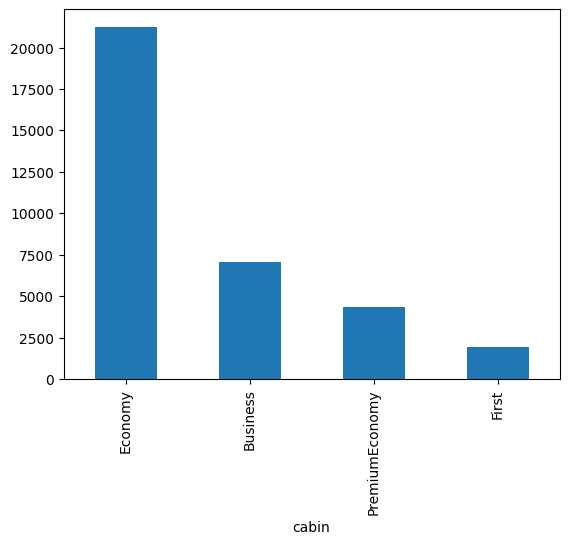

In [24]:
df["cabin"].value_counts().plot.bar()

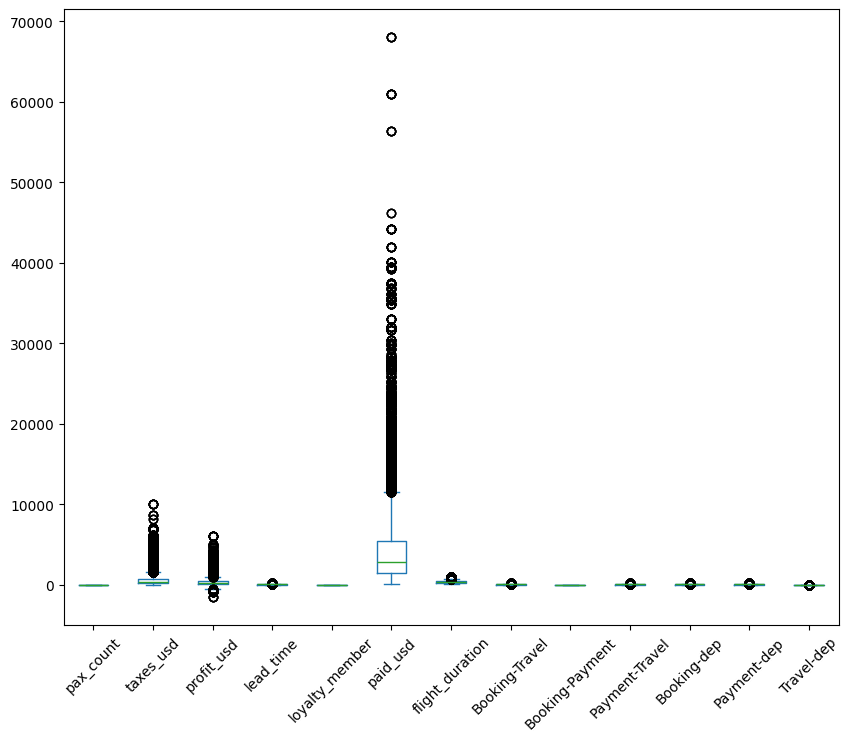

In [25]:
df.select_dtypes(include=["int", "float"]).plot.box(figsize=(10, 8)),
plt.xticks(rotation=45)
plt.show()

In [26]:
df["booking_year"] = df["booking_date"].dt.year
#df["booking_month"] = df["booking_date"].dt.month
df["booking_day"] = df["booking_date"].dt.day

df["travel_year"] = df["travel_date"].dt.year
#df["travel_month"] = df["travel_date"].dt.month
df["travel_day"] = df["travel_date"].dt.day

df["payment_year"] = df["payment_date"].dt.year
#df["payment_month"] = df["payment_date"].dt.month
df["payment_day"] = df["payment_date"].dt.day

df["dep_year"] = df["dep_date"].dt.year
#df["dep_month"] = df["dep_date"].dt.month
df["dep_day"] = df["dep_date"].dt.day

In [27]:
df.drop(["booking_date", "travel_date", "payment_date", "dep_date", "profit_usd", "taxes_usd"], axis=1, inplace=True)

In [28]:
df.shape

(34593, 35)

In [29]:
df.columns

Index(['channel', 'trip_type', 'cabin', 'airline', 'origin', 'destination',
       'pax_count', 'lead_time', 'season', 'passenger_type', 'gender',
       'nationality', 'loyalty_member', 'payment_method', 'paid_usd',
       'dep_airport', 'arr_airport', 'dep_city', 'arr_city', 'flight_duration',
       'stop_type', 'Booking-Travel', 'Booking-Payment', 'Payment-Travel',
       'Booking-dep', 'Payment-dep', 'Travel-dep', 'booking_year',
       'booking_day', 'travel_year', 'travel_day', 'payment_year',
       'payment_day', 'dep_year', 'dep_day'],
      dtype='str')

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34593 entries, 0 to 34592
Data columns (total 35 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   channel          34593 non-null  str    
 1   trip_type        34593 non-null  str    
 2   cabin            34593 non-null  str    
 3   airline          34593 non-null  str    
 4   origin           34593 non-null  str    
 5   destination      34593 non-null  str    
 6   pax_count        34593 non-null  int64  
 7   lead_time        34593 non-null  int64  
 8   season           34593 non-null  str    
 9   passenger_type   34593 non-null  str    
 10  gender           34593 non-null  str    
 11  nationality      34593 non-null  str    
 12  loyalty_member   34593 non-null  int64  
 13  payment_method   34593 non-null  str    
 14  paid_usd         34593 non-null  float64
 15  dep_airport      34593 non-null  str    
 16  arr_airport      34593 non-null  str    
 17  dep_city         34593 

# Advanced Data Preprocessing

In [31]:
# Split Target Variable

X = df.drop("season", axis=1)
y = df["season"]

In [32]:
# Encode y
le = LabelEncoder()

y = le.fit_transform(y)

In [33]:
# Seperate data based on types
cat_cols = []
num_cols = []

for i in X.columns:
    if X[i].dtypes == "str":
        cat_cols.append(i)
    else:
        num_cols.append(i)

In [34]:
# Split data into train and test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
# Preprocess the whole features

preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(), cat_cols),
                  ("num", StandardScaler(), num_cols)
                 ])

transformed_data = preprocessor.fit_transform(X_train)

new_cat_cols = preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)

all_cols = list(new_cat_cols) + list(num_cols)

X_train = pd.DataFrame(transformed_data.toarray(), columns=all_cols)

# Model Building

In [36]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [37]:
model.score(X_train, y_train)

1.0

In [38]:
X_test = preprocessor.transform(X_test)

In [39]:
model.score(X_test, y_test)

C:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


0.9566411331117214

In [40]:
y_pred = model.predict(X_test)

C:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [41]:
cls_rep = classification_report(y_test, y_pred)
print(cls_rep)

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1673
           1       0.95      0.96      0.95      1713
           2       0.95      0.95      0.95      1785
           3       0.97      0.96      0.97      1748

    accuracy                           0.96      6919
   macro avg       0.96      0.96      0.96      6919
weighted avg       0.96      0.96      0.96      6919



In [42]:
importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance.sort_values(ascending=False)

paid_usd                 0.037291
payment_day              0.030441
flight_duration          0.030438
Payment-Travel           0.030027
travel_day               0.029981
                           ...   
dep_city_Johannesburg    0.000170
origin_SYD               0.000169
origin_MEL               0.000162
origin_LHR               0.000142
origin_BEY               0.000106
Length: 630, dtype: float64

In [43]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(RandomForestClassifier(), X_train, y_train, cv=skf, scoring="accuracy")

In [44]:
print("Accuracy Scores: ", scores)
print("Mean Accuracy ", scores.mean())

Accuracy Scores:  [0.93459801 0.9266486  0.92520325 0.9232159  0.92916516]
Mean Accuracy  0.9277661848296594


# Saving Artifacts and Data

In [45]:
os.makedirs("artifact", exist_ok=True)

In [46]:
# Save model
joblib.dump(model, r"C:\Users\USER\Documents\MY PORTFOLIO\Smart Travel Recommendation System\artifact\travel_model.pkl")
joblib.dump(le, r"C:\Users\USER\Documents\MY PORTFOLIO\Smart Travel Recommendation System\artifact\target_label.pkl")
joblib.dump(preprocessor, r"C:\Users\USER\Documents\MY PORTFOLIO\Smart Travel Recommendation System\artifact\feature_preprocessor.pkl")

['C:\\Users\\USER\\Documents\\MY PORTFOLIO\\Smart Travel Recommendation System\\artifact\\feature_preprocessor.pkl']

In [47]:
df.to_csv(r"C:\Users\USER\Documents\MY PORTFOLIO\Smart Travel Recommendation System\Travel Agency\cleaned_data.csv", index=False)